# Model Evaluation

This notebook produces the full evaluation of all trained models and the SMOTE class-imbalance experiment.

**Contents:**
1. Load models and reconstruct test set
2. Confusion matrices for all models
3. Classification reports
4. ROC curves (all models on one plot)
5. Precision-Recall curves
6. Feature importance (Random Forest and XGBoost)
7. SMOTE experiment: does oversampling improve results on this dataset?
8. Final comparison table

## 1. Setup

In [1]:
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection  import train_test_split
from sklearn.preprocessing    import StandardScaler
from sklearn.tree             import DecisionTreeClassifier
from sklearn.ensemble         import RandomForestClassifier
from sklearn.neighbors        import KNeighborsClassifier
from sklearn.metrics          import (accuracy_score, precision_score, recall_score,
                                      f1_score, roc_auc_score, average_precision_score,
                                      confusion_matrix, roc_curve, precision_recall_curve,
                                      classification_report)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42
FIG_DIR      = '../figures'
MODELS_DIR   = '../models'

## 2. Reconstruct Train / Test Split

Using the same `random_state=42` and split parameters as the training notebook ensures the test set is identical.

In [2]:
df = pd.read_csv('../data/processed/merged_features.csv', parse_dates=['date'])

feature_cols = [c for c in df.columns
                if c not in ['machineID', 'date', 'failure_within_24h', 'failure_component']]
X = df[feature_cols]
y = df['failure_within_24h']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

scaler       = joblib.load(f'{MODELS_DIR}/scaler.joblib')
X_train_sc   = scaler.transform(X_train)
X_test_sc    = scaler.transform(X_test)

scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

print(f'Test set: {X_test.shape[0]:,} rows, {y_test.sum()} positives')

Test set: 7,320 rows, 144 positives


## 3. Load Trained Models

In [3]:
dt_model   = joblib.load(f'{MODELS_DIR}/decision_tree.joblib')
rf_base    = joblib.load(f'{MODELS_DIR}/random_forest_baseline.joblib')
xgb_base   = joblib.load(f'{MODELS_DIR}/xgboost_baseline.joblib')
knn_model  = joblib.load(f'{MODELS_DIR}/knn_best.joblib')
rf_tuned   = joblib.load(f'{MODELS_DIR}/random_forest_tuned.joblib')
xgb_tuned  = joblib.load(f'{MODELS_DIR}/xgboost_tuned.joblib')

# (name, model, X_test to use)
all_models = [
    ('Decision Tree',          dt_model,  X_test),
    ('Random Forest',          rf_base,   X_test),
    ('XGBoost',                xgb_base,  X_test),
    ('k-NN',                   knn_model, X_test_sc),
    ('Random Forest (tuned)',  rf_tuned,  X_test),
    ('XGBoost (tuned)',        xgb_tuned, X_test),
]

print('Models loaded:', [m[0] for m in all_models])

Models loaded: ['Decision Tree', 'Random Forest', 'XGBoost', 'k-NN', 'Random Forest (tuned)', 'XGBoost (tuned)']


## 4. Compute All Metrics

In [4]:
def get_metrics(name, model, Xte, yte):
    pred = model.predict(Xte)
    prob = model.predict_proba(Xte)[:, 1]
    return {
        'Model':      name,
        'Accuracy':   round(accuracy_score(yte, pred), 4),
        'Precision':  round(precision_score(yte, pred, zero_division=0), 4),
        'Recall':     round(recall_score(yte, pred, zero_division=0), 4),
        'F1':         round(f1_score(yte, pred, zero_division=0), 4),
        'ROC-AUC':    round(roc_auc_score(yte, prob), 4),
        'Avg Prec':   round(average_precision_score(yte, prob), 4),
    }

metrics_list = [get_metrics(name, model, Xte, y_test)
                for name, model, Xte in all_models]
metrics_df = pd.DataFrame(metrics_list).set_index('Model').sort_values('F1', ascending=False)

print('Full metrics table:')
display(metrics_df)

Full metrics table:


,Accuracy,Precision,Recall,F1,ROC-AUC,Avg Prec
Model,,,,,,
Random Forest (tuned),0.9989,0.9658,0.9792,0.9724,0.9999,0.9974
XGBoost,0.9988,0.9470,0.9931,0.9695,0.9999,0.9970
Random Forest,0.9988,0.9592,0.9792,0.9691,1.0000,0.9976
XGBoost (tuned),0.9986,0.9408,0.9931,0.9662,1.0000,0.9984
k-NN,0.9980,0.9108,0.9931,0.9502,0.9997,0.9759
Decision Tree,0.9980,0.9388,0.9583,0.9485,0.9785,0.9005


## 5. Confusion Matrices

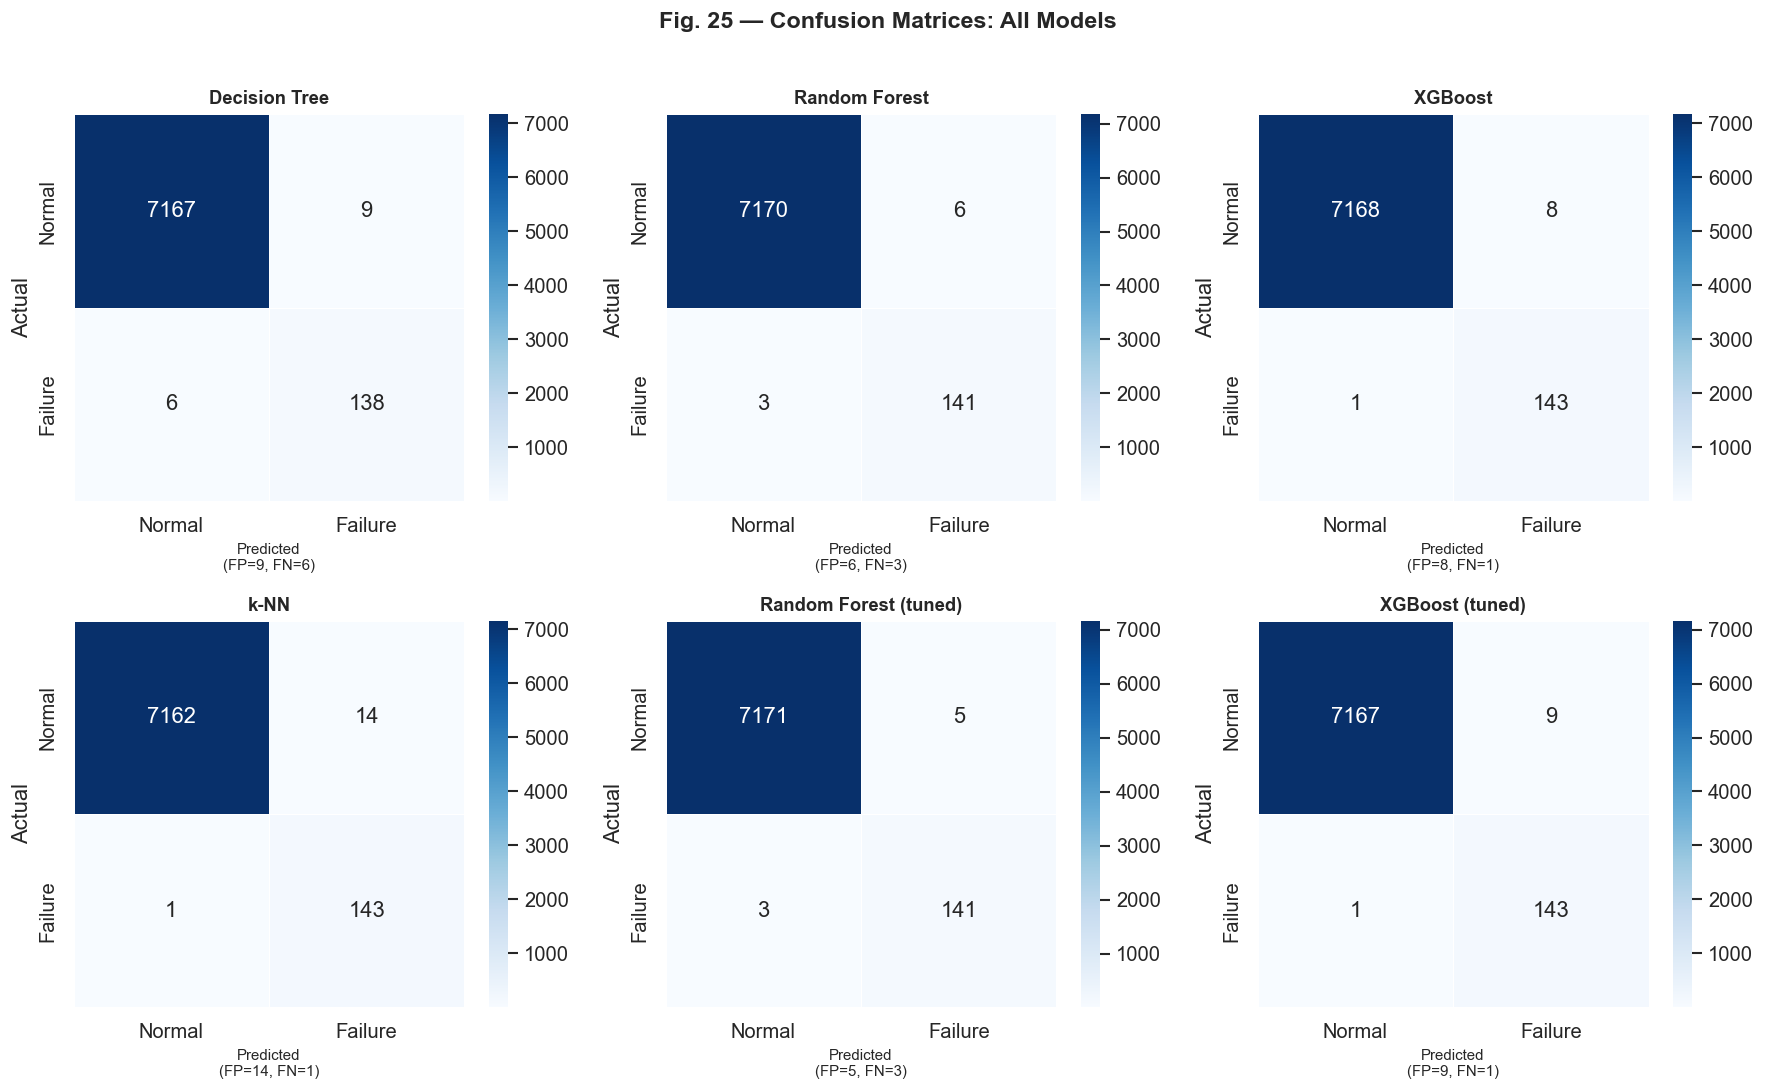

Note: False Negatives (FN) are the costlier error type.
A missed failure is more damaging than a false alarm in most industrial settings.


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, (name, model, Xte) in enumerate(all_models):
    pred = model.predict(Xte)
    cm   = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Normal', 'Failure'],
                yticklabels=['Normal', 'Failure'],
                linewidths=0.5)
    axes[i].set_title(name, fontweight='bold', fontsize=11)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

    tn, fp, fn, tp = cm.ravel()
    axes[i].set_xlabel(f'Predicted\n(FP={fp}, FN={fn})', fontsize=9)

plt.suptitle('Fig. 25 — Confusion Matrices: All Models', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

print('Note: False Negatives (FN) are the costlier error type.')
print('A missed failure is more damaging than a false alarm in most industrial settings.')

## 6. Classification Reports

In [6]:
for name, model, Xte in all_models:
    pred = model.predict(Xte)
    print(f'--- {name} ---')
    print(classification_report(y_test, pred, target_names=['Normal', 'Failure'], zero_division=0))
    print()

--- Decision Tree ---
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      7176
     Failure       0.94      0.96      0.95       144

    accuracy                           1.00      7320
   macro avg       0.97      0.98      0.97      7320
weighted avg       1.00      1.00      1.00      7320


--- Random Forest ---
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      7176
     Failure       0.96      0.98      0.97       144

    accuracy                           1.00      7320
   macro avg       0.98      0.99      0.98      7320
weighted avg       1.00      1.00      1.00      7320


--- XGBoost ---
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      7176
     Failure       0.95      0.99      0.97       144

    accuracy                           1.00      7320
   macro avg       0.97      1.00      0.98      7320
weighted avg

--- k-NN ---
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      7176
     Failure       0.91      0.99      0.95       144

    accuracy                           1.00      7320
   macro avg       0.96      1.00      0.97      7320
weighted avg       1.00      1.00      1.00      7320


--- Random Forest (tuned) ---
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      7176
     Failure       0.97      0.98      0.97       144

    accuracy                           1.00      7320
   macro avg       0.98      0.99      0.99      7320
weighted avg       1.00      1.00      1.00      7320


--- XGBoost (tuned) ---
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      7176
     Failure       0.94      0.99      0.97       144

    accuracy                           1.00      7320
   macro avg       0.97      1.00      0.98      7320
weigh

## 7. ROC Curves

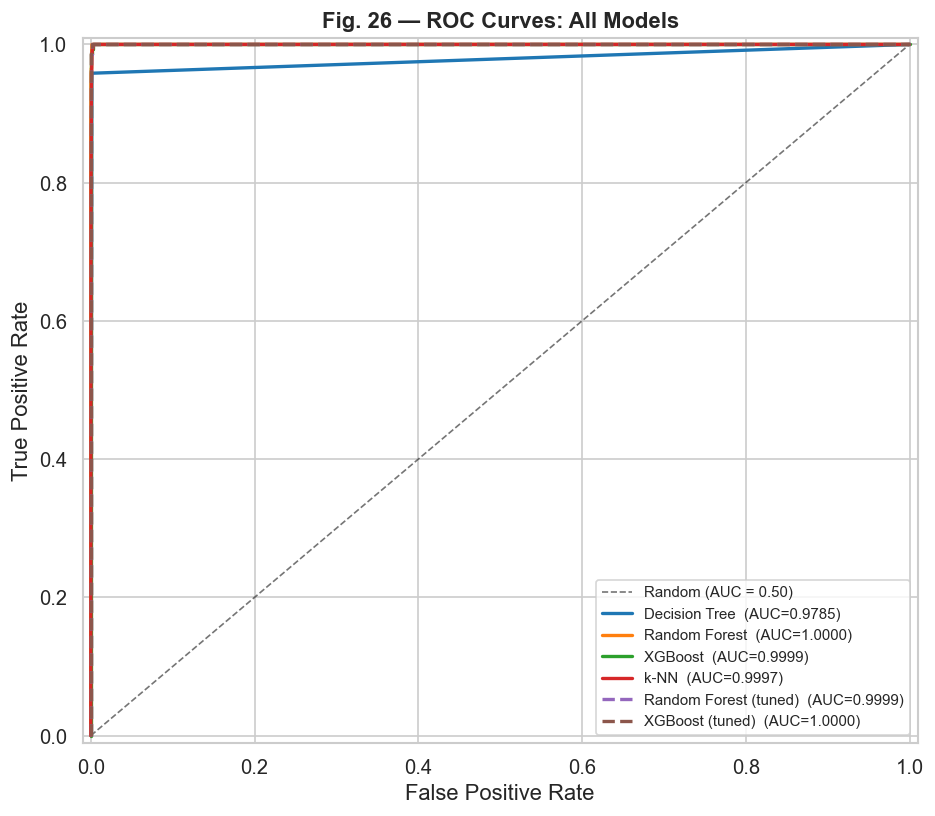

In [7]:
palette = sns.color_palette('tab10', len(all_models))
line_styles = ['-', '-', '-', '-', '--', '--']

fig, ax = plt.subplots(figsize=(8, 7))
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.50)', alpha=0.6)

for i, (name, model, Xte) in enumerate(all_models):
    prob = model.predict_proba(Xte)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, linewidth=2, color=palette[i],
            linestyle=line_styles[i], label=f'{name}  (AUC={auc:.4f})')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Fig. 26 — ROC Curves: All Models', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(-0.01, 1.01)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Precision-Recall Curves

ROC curves can be overly optimistic on imbalanced datasets. Precision-Recall curves show the actual trade-off between false positives and false negatives at different decision thresholds, and are more informative when the positive class is rare (~2% here).

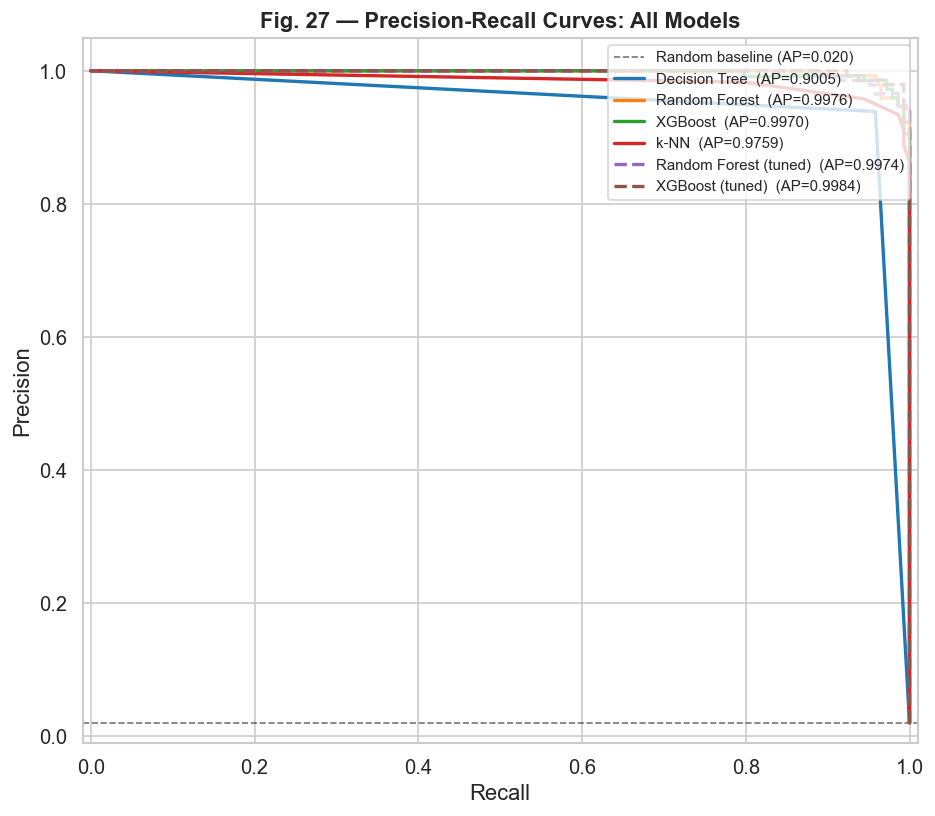

In [8]:
fig, ax = plt.subplots(figsize=(8, 7))

baseline_ap = y_test.mean()
ax.axhline(baseline_ap, color='k', linestyle='--', linewidth=1,
           label=f'Random baseline (AP={baseline_ap:.3f})', alpha=0.6)

for i, (name, model, Xte) in enumerate(all_models):
    prob = model.predict_proba(Xte)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    ax.plot(rec, prec, linewidth=2, color=palette[i],
            linestyle=line_styles[i], label=f'{name}  (AP={ap:.4f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Fig. 27 — Precision-Recall Curves: All Models', fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(-0.01, 1.05)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/pr_curves.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Feature Importance

### 9.1 Random Forest (tuned) — top 20 features

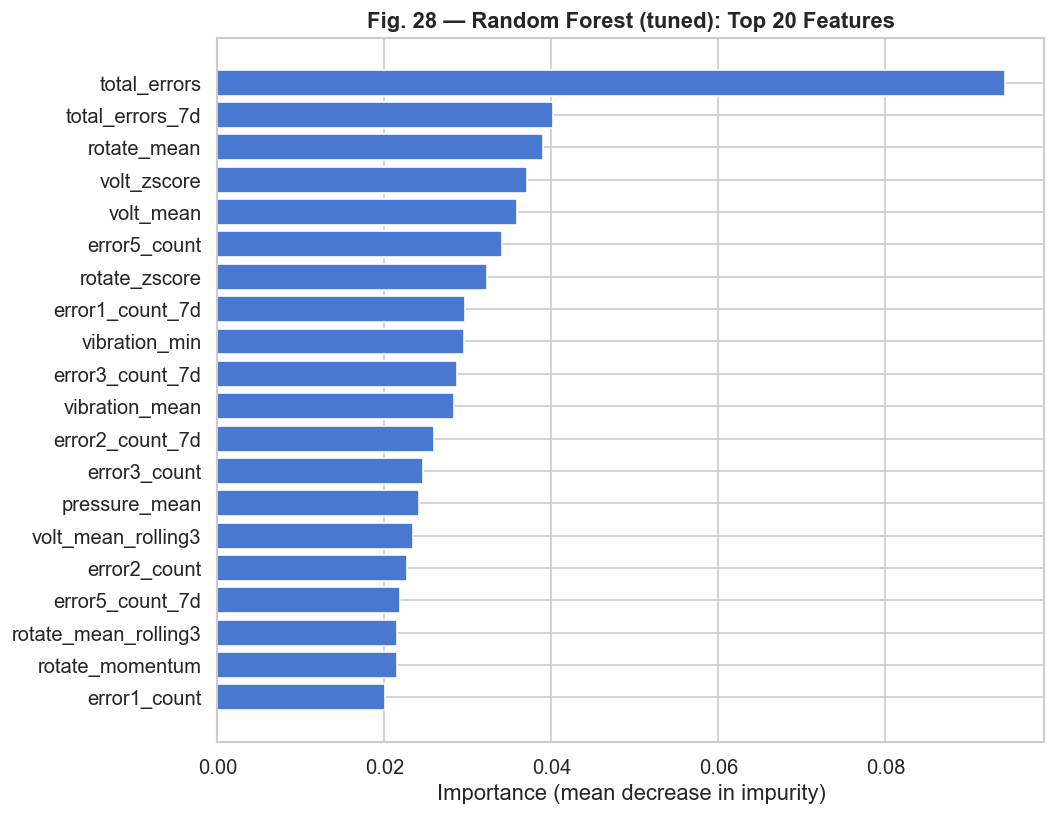

In [9]:
rf_importances = pd.Series(
    rf_tuned.feature_importances_, index=feature_cols
).sort_values(ascending=False)

top_n = 20
top_rf = rf_importances.head(top_n).sort_values()

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(top_rf.index, top_rf.values,
               color=sns.color_palette('muted')[0], edgecolor='white')
ax.set_xlabel('Importance (mean decrease in impurity)')
ax.set_title(f'Fig. 28 — Random Forest (tuned): Top {top_n} Features', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/rf_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

### 9.2 XGBoost (tuned) — top 20 features

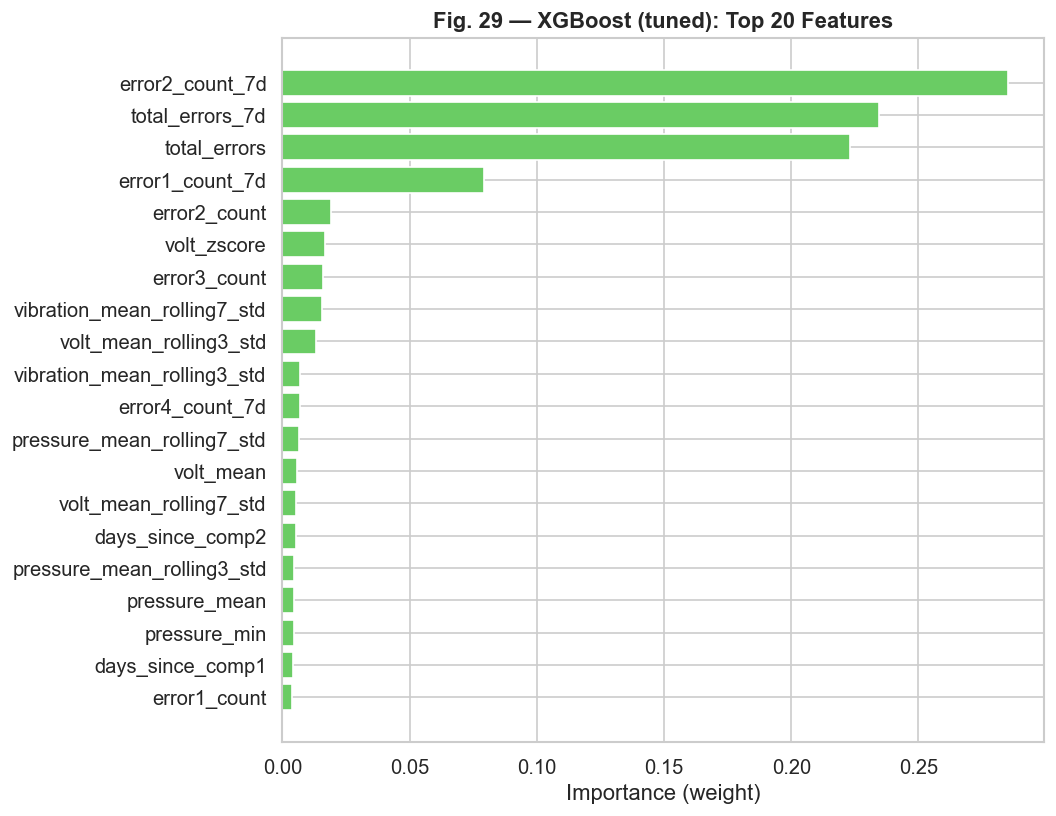

In [10]:
xgb_importances = pd.Series(
    xgb_tuned.feature_importances_, index=feature_cols
).sort_values(ascending=False)

top_xgb = xgb_importances.head(top_n).sort_values()

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top_xgb.index, top_xgb.values,
        color=sns.color_palette('muted')[2], edgecolor='white')
ax.set_xlabel('Importance (weight)')
ax.set_title(f'Fig. 29 — XGBoost (tuned): Top {top_n} Features', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/xgb_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

### 9.3 Feature importance comparison: RF vs. XGBoost

In [11]:
# Top 15 from each model — what do they agree on?
top15_rf  = set(rf_importances.head(15).index)
top15_xgb = set(xgb_importances.head(15).index)
shared = top15_rf & top15_xgb
print(f'Top-15 features shared by RF and XGBoost ({len(shared)}):')  
for f in sorted(shared):
    print(f'  {f:40s}  RF rank: {list(rf_importances.index).index(f)+1:2d}  XGB rank: {list(xgb_importances.index).index(f)+1:2d}')

print()
print('Only in RF top-15 :', sorted(top15_rf  - top15_xgb))
print('Only in XGB top-15:', sorted(top15_xgb - top15_rf))

Top-15 features shared by RF and XGBoost (7):
  error1_count_7d                           RF rank:  8  XGB rank:  4
  error2_count_7d                           RF rank: 12  XGB rank:  1
  error3_count                              RF rank: 13  XGB rank:  7
  total_errors                              RF rank:  1  XGB rank:  3
  total_errors_7d                           RF rank:  2  XGB rank:  2
  volt_mean                                 RF rank:  5  XGB rank: 13
  volt_zscore                               RF rank:  4  XGB rank:  6

Only in RF top-15 : ['error3_count_7d', 'error5_count', 'pressure_mean', 'rotate_mean', 'rotate_zscore', 'vibration_mean', 'vibration_min', 'volt_mean_rolling3']
Only in XGB top-15: ['days_since_comp2', 'error2_count', 'error4_count_7d', 'pressure_mean_rolling7_std', 'vibration_mean_rolling3_std', 'vibration_mean_rolling7_std', 'volt_mean_rolling3_std', 'volt_mean_rolling7_std']


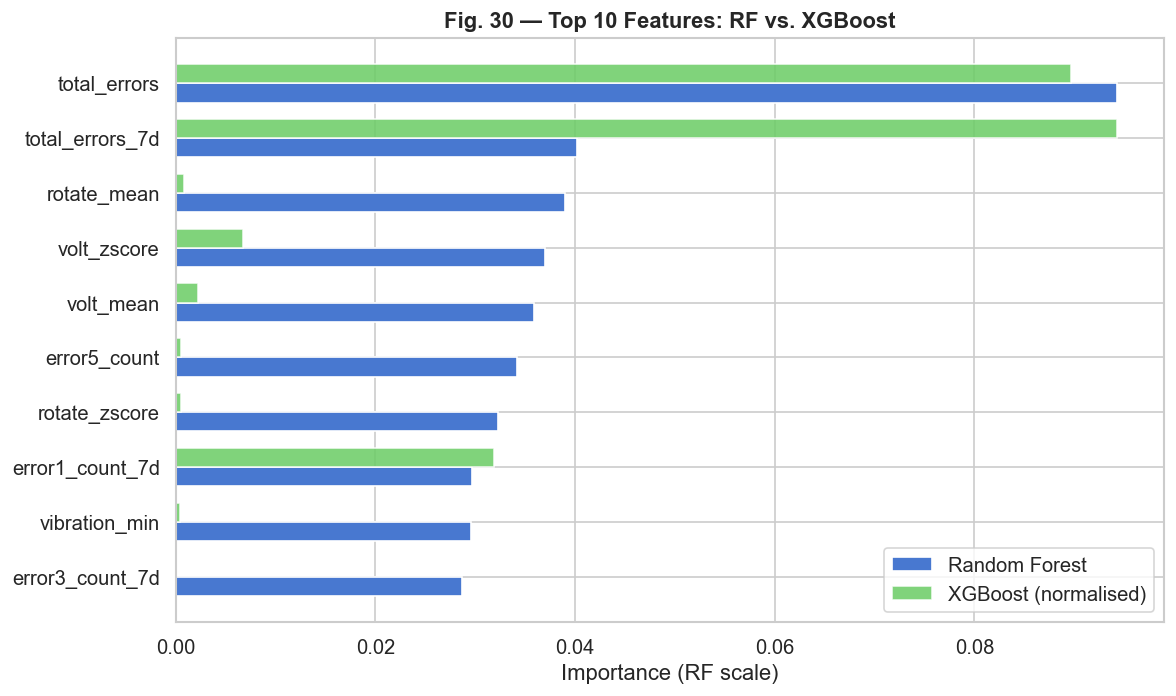

In [12]:
# Side-by-side for shared top-10
top10_both = (rf_importances.head(10).rename('RandomForest')
              .to_frame()
              .join(xgb_importances.rename('XGBoost'), how='outer')
              .fillna(0))
top10_both = top10_both.loc[rf_importances.head(10).index]  # keep RF ordering
top10_both = top10_both.sort_values('RandomForest')

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(top10_both))
width = 0.35
ax.barh(x - width/2, top10_both['RandomForest'], width,
        label='Random Forest', color=sns.color_palette('muted')[0], edgecolor='white')
ax.barh(x + width/2, top10_both['XGBoost'] / top10_both['XGBoost'].max() * top10_both['RandomForest'].max(),
        width, label='XGBoost (normalised)', color=sns.color_palette('muted')[2],
        edgecolor='white', alpha=0.85)
ax.set_yticks(x)
ax.set_yticklabels(top10_both.index)
ax.set_xlabel('Importance (RF scale)')
ax.set_title('Fig. 30 — Top 10 Features: RF vs. XGBoost', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/feature_importance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 10. SMOTE Experiment

SMOTE (Synthetic Minority Oversampling Technique) generates synthetic positive examples by interpolating between existing ones in feature space. The idea is to give the model more minority-class examples to learn from.

In this experiment we apply SMOTE to the training set, retrain Random Forest (tuned) and XGBoost (tuned), then compare results against the non-SMOTE versions. This directly tests whether oversampling helps or hurts on this specific dataset.

In [13]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f'Before SMOTE: {y_train.value_counts().to_dict()}')
print(f'After SMOTE : {pd.Series(y_train_sm).value_counts().to_dict()}')
print(f'Training set size after SMOTE: {len(X_train_sm):,}')

Before SMOTE: {0: 28706, 1: 574}
After SMOTE : {0: 28706, 1: 28706}
Training set size after SMOTE: 57,412


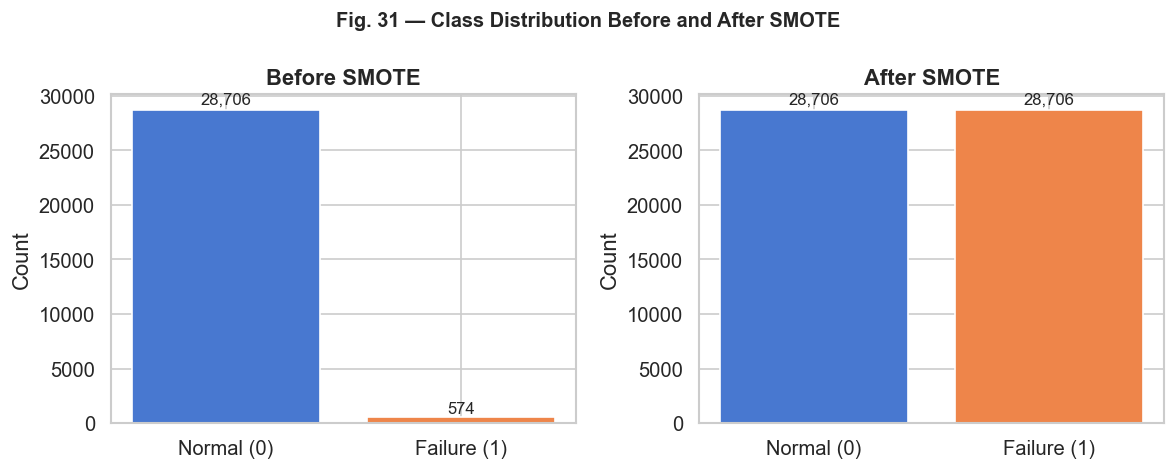

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
palette_2 = sns.color_palette('muted', 2)

for ax, (counts, title) in zip(axes, [
    (y_train.value_counts().sort_index(), 'Before SMOTE'),
    (pd.Series(y_train_sm).value_counts().sort_index(), 'After SMOTE'),
]):
    bars = ax.bar(['Normal (0)', 'Failure (1)'], counts.values,
                  color=palette_2, edgecolor='white')
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'{val:,}', ha='center', va='bottom', fontsize=10)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')

fig.suptitle('Fig. 31 — Class Distribution Before and After SMOTE', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/smote_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [15]:
smote_results = []

for name, ModelClass, params, Xte in [
    ('RF + SMOTE',  RandomForestClassifier, rf_tuned.get_params(),  X_test),
    ('XGB + SMOTE', XGBClassifier,          xgb_tuned.get_params(), X_test),
]:
    clf = ModelClass(**params)
    clf.fit(X_train_sm, y_train_sm)
    pred = clf.predict(Xte)
    prob = clf.predict_proba(Xte)[:, 1]
    smote_results.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_test, pred), 4),
        'Precision': round(precision_score(y_test, pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_test, pred, zero_division=0), 4),
        'F1':        round(f1_score(y_test, pred, zero_division=0), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, prob), 4),
        'Avg Prec':  round(average_precision_score(y_test, prob), 4),
    })

smote_df = pd.DataFrame(smote_results).set_index('Model')
print('SMOTE model results:')
display(smote_df)

SMOTE model results:


,Accuracy,Precision,Recall,F1,ROC-AUC,Avg Prec
Model,,,,,,
RF + SMOTE,0.9986,0.9408,0.9931,0.9662,0.9998,0.9877
XGB + SMOTE,0.9988,0.9412,1.0000,0.9697,0.9999,0.9970


With vs. without SMOTE:


,Accuracy,Precision,Recall,F1,ROC-AUC,Avg Prec
Model,,,,,,
Random Forest (tuned),0.9989,0.9658,0.9792,0.9724,0.9999,0.9974
RF + SMOTE,0.9986,0.9408,0.9931,0.9662,0.9998,0.9877
XGBoost (tuned),0.9986,0.9408,0.9931,0.9662,1.0000,0.9984
XGB + SMOTE,0.9988,0.9412,1.0000,0.9697,0.9999,0.9970


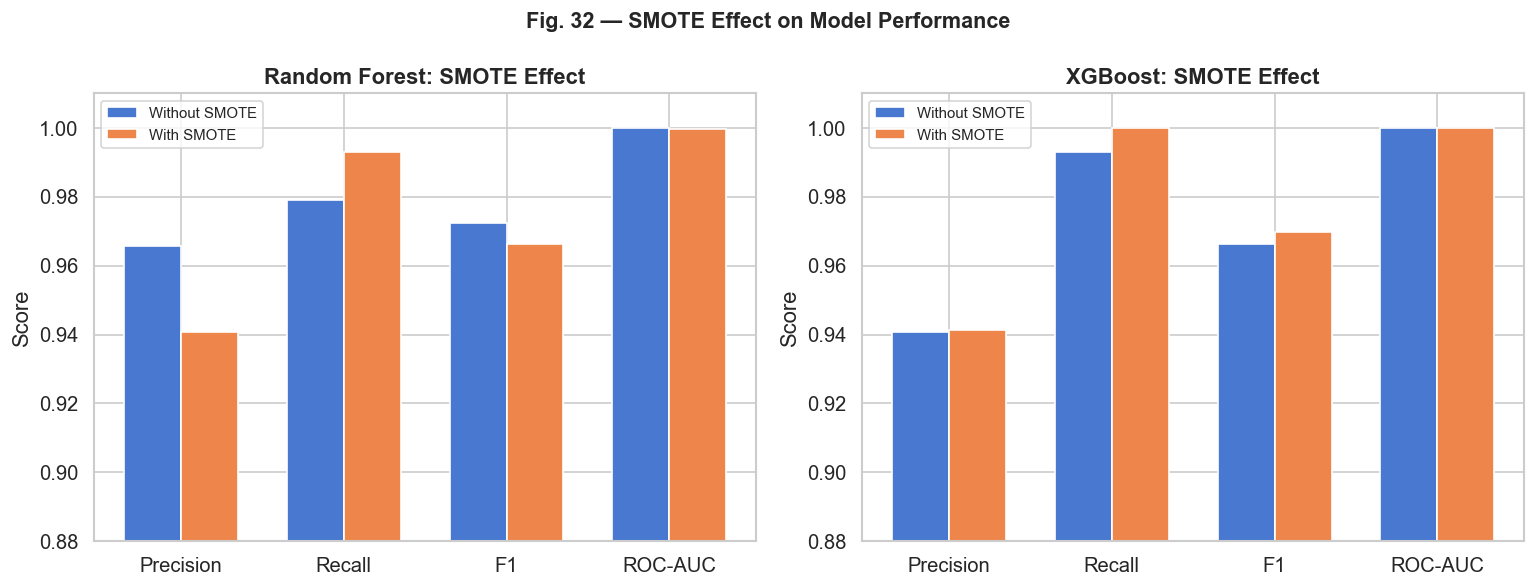

In [16]:
# Compare with / without SMOTE side by side
compare_names = ['Random Forest (tuned)', 'RF + SMOTE', 'XGBoost (tuned)', 'XGB + SMOTE']
compare_df = pd.concat([metrics_df, smote_df]).loc[compare_names]

print('With vs. without SMOTE:')
display(compare_df)

# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
compare_metrics = ['Precision', 'Recall', 'F1', 'ROC-AUC']
palette_4 = sns.color_palette('muted', 4)

for ax, (base_name, smote_name, model_label) in zip(axes, [
    ('Random Forest (tuned)', 'RF + SMOTE', 'Random Forest'),
    ('XGBoost (tuned)',       'XGB + SMOTE', 'XGBoost'),
]):
    x = np.arange(len(compare_metrics))
    width = 0.35
    base_vals  = compare_df.loc[base_name,  compare_metrics].values.astype(float)
    smote_vals = compare_df.loc[smote_name, compare_metrics].values.astype(float)
    ax.bar(x - width/2, base_vals,  width, label='Without SMOTE',
           color=palette_4[0], edgecolor='white')
    ax.bar(x + width/2, smote_vals, width, label='With SMOTE',
           color=palette_4[1], edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(compare_metrics)
    ax.set_ylim(0.88, 1.01)
    ax.set_ylabel('Score')
    ax.set_title(f'{model_label}: SMOTE Effect', fontweight='bold')
    ax.legend(fontsize=9)

fig.suptitle('Fig. 32 — SMOTE Effect on Model Performance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/smote_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 11. Final Comparison Table

All models and variants ranked by F1 score.

In [17]:
final_df = pd.concat([metrics_df, smote_df]).sort_values('F1', ascending=False)
print('Final ranking (all models):')
display(final_df)

best = final_df.index[0]
print(f'\nBest model: {best}')
print(f'  F1      : {final_df.loc[best, "F1"]}')
print(f'  ROC-AUC : {final_df.loc[best, "ROC-AUC"]}')
print(f'  Precision: {final_df.loc[best, "Precision"]}')
print(f'  Recall  : {final_df.loc[best, "Recall"]}')

Final ranking (all models):


,Accuracy,Precision,Recall,F1,ROC-AUC,Avg Prec
Model,,,,,,
Random Forest (tuned),0.9989,0.9658,0.9792,0.9724,0.9999,0.9974
XGB + SMOTE,0.9988,0.9412,1.0000,0.9697,0.9999,0.9970
XGBoost,0.9988,0.9470,0.9931,0.9695,0.9999,0.9970
Random Forest,0.9988,0.9592,0.9792,0.9691,1.0000,0.9976
XGBoost (tuned),0.9986,0.9408,0.9931,0.9662,1.0000,0.9984
RF + SMOTE,0.9986,0.9408,0.9931,0.9662,0.9998,0.9877
k-NN,0.9980,0.9108,0.9931,0.9502,0.9997,0.9759
Decision Tree,0.9980,0.9388,0.9583,0.9485,0.9785,0.9005



Best model: Random Forest (tuned)
  F1      : 0.9724
  ROC-AUC : 0.9999
  Precision: 0.9658
  Recall  : 0.9792


## 12. Summary of Findings

Key observations from the evaluation:

In [18]:
print('1. Class imbalance')
print('   The dataset has a ~50:1 negative-to-positive ratio.')
print('   Despite this, all models achieve F1 > 0.94 because the engineered features')
print('   (rolling sensor stats, error counts, days since maintenance) create strong separation.')
print()
print('2. SMOTE effect')
rf_f1_base  = metrics_df.loc['Random Forest (tuned)', 'F1']
rf_f1_smote = smote_df.loc['RF + SMOTE', 'F1']
xgb_f1_base  = metrics_df.loc['XGBoost (tuned)', 'F1']
xgb_f1_smote = smote_df.loc['XGB + SMOTE', 'F1']
print(f'   RF:  without SMOTE F1={rf_f1_base}, with SMOTE F1={rf_f1_smote}  (delta={rf_f1_smote-rf_f1_base:+.4f})')
print(f'   XGB: without SMOTE F1={xgb_f1_base}, with SMOTE F1={xgb_f1_smote}  (delta={xgb_f1_smote-xgb_f1_base:+.4f})')
print('   SMOTE does not improve either model here because the features already provide')
print('   enough discriminative signal for the minority class.')
print()
print('3. Most informative features (agreed by RF and XGBoost):')
top5_shared = [f for f in rf_importances.head(15).index if f in xgb_importances.head(15).index][:5]
for f in top5_shared:
    print(f'   - {f}')
print()
print('4. Decision Tree vs. ensemble methods')
dt_f1 = metrics_df.loc['Decision Tree', 'F1']
rf_f1 = metrics_df.loc['Random Forest', 'F1']
print(f'   Single DT: F1={dt_f1}  |  Random Forest: F1={rf_f1}')
print('   The ensemble reduces variance from individual unstable trees.')

1. Class imbalance
   The dataset has a ~50:1 negative-to-positive ratio.
   Despite this, all models achieve F1 > 0.94 because the engineered features
   (rolling sensor stats, error counts, days since maintenance) create strong separation.

2. SMOTE effect
   RF:  without SMOTE F1=0.9724, with SMOTE F1=0.9662  (delta=-0.0062)
   XGB: without SMOTE F1=0.9662, with SMOTE F1=0.9697  (delta=+0.0035)
   SMOTE does not improve either model here because the features already provide
   enough discriminative signal for the minority class.

3. Most informative features (agreed by RF and XGBoost):
   - total_errors
   - total_errors_7d
   - volt_zscore
   - volt_mean
   - error1_count_7d

4. Decision Tree vs. ensemble methods
   Single DT: F1=0.9485  |  Random Forest: F1=0.9691
   The ensemble reduces variance from individual unstable trees.
